# 03 · Denoising Diffusion (DDPM)

**Generative Modelling for HEP** — notebook 3 of 6.

A diffusion model learns to *reverse noise*. The **forward** process slowly
corrupts data into pure Gaussian noise over many small steps; a network then
learns the **reverse** process — at each step it looks at a noisy sample and
**predicts the noise** that was added, so we can subtract a little of it and
walk back toward clean data.

We do the **mechanism first**, by hand, on a tiny **2D point cloud** (eight
Gaussians) with a 2-layer MLP — you'll watch points dissolve into noise and
then re-condense. Only *then* do we reach for `diffusers` to grow a brand-new
**creature sprite** 🐲 out of noise and animate it emerging frame by frame.

> You complete the cells marked **Exercise** — most ask for a number or a
> line of code, a few ask for a short **written reflection**, and one asks you
> to **submit a gif**. Everything else runs as-is.

In [2]:
%load_ext cadence
# Loads the cadence magics + the input transformer that comments out
# `# cadence:starter` regions, so the scaffold placeholders never run.

## Setup

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import sys; sys.path.insert(0, "..")
from src.seeds import set_seed
from src.train import get_device, to_loader, train
from src.data import load_images
from src.diffusion import (make_beta_schedule, q_sample, ddpm_p_losses,
                           ddpm_sample, make_unet, make_scheduler)

SEED = 0
TIMESTEPS = 200       # diffusion steps for the 2D toy
EPOCHS = 40           # 2D toy trains in seconds; sprite model is configured below
BATCH = 256
set_seed(SEED)
device = get_device()
print(f"device={device}  timesteps={TIMESTEPS}  epochs={EPOCHS}")

device=cpu  timesteps=200  epochs=40


## Part A · The mechanism, by hand, in 2D

Before any fancy image model, we build the whole DDPM loop on a 2D toy so the
moving parts are visible. We make an **eight-Gaussians** ring inline with numpy,
set up a **linear variance schedule** (`make_beta_schedule`), and define a tiny
**MLP noise predictor** that takes a noisy point `x_t` and the timestep `t` and
outputs its guess of the noise.

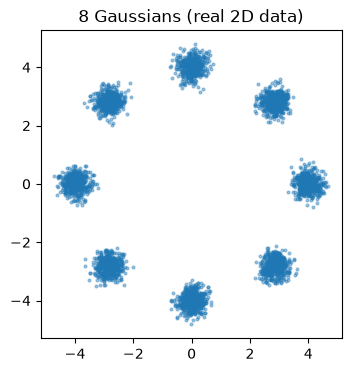

ToyMLP params: 17282


In [4]:
def eight_gaussians(n=4000, radius=4.0, std=0.25, seed=0):
    """A ring of 8 Gaussian blobs — a classic 2D generative-model testbed."""
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    which = rng.integers(0, 8, size=n)
    pts = centers[which] + rng.normal(0, std, size=(n, 2))
    return pts.astype(np.float32)

points = eight_gaussians(n=4000, seed=SEED)
# normalise to unit-ish scale so the schedule (which ends near unit variance) fits
data_mean = points.mean(0, keepdims=True)
data_std = points.std(0, keepdims=True)
points_norm = (points - data_mean) / data_std
X2d = torch.as_tensor(points_norm, dtype=torch.float32)
toy_loader = to_loader(X2d, batch_size=BATCH)

sched = make_beta_schedule(timesteps=TIMESTEPS)        # dict of 1-D tensors

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(points[:, 0], points[:, 1], s=4, alpha=0.4)
ax.set_title("8 Gaussians (real 2D data)"); ax.set_aspect("equal"); plt.show()


class ToyMLP(nn.Module):
    """2-layer MLP noise predictor: (x_t, t) -> predicted noise, shape (B, 2).
    The timestep enters as a single normalised scalar feature."""
    def __init__(self, hidden=128, timesteps=TIMESTEPS):
        super().__init__()
        self.timesteps = timesteps
        self.net = nn.Sequential(
            nn.Linear(2 + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2))

    def forward(self, x, t):
        t_feat = (t.float() / self.timesteps).view(-1, 1)
        return self.net(torch.cat([x, t_feat], dim=1))

toy_model = ToyMLP().to(device)
print("ToyMLP params:", sum(p.numel() for p in toy_model.parameters()))

### Exercise 1 — Forward noising with `q_sample`

The forward process adds noise in one shot:
$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon,
  \qquad \epsilon \sim \mathcal N(0, I).$$

Use `q_sample(x0, t, sched)` to noise the **whole** 2D dataset to the **last**
timestep (`T-1`). By construction the data was standardised, so at the final
step `x_t` should be almost pure unit-variance noise. Compute the **empirical
variance** of the noised points and return it as `var_last` — it should land
close to **1.0**.

In [ ]:
# cadence:checkpoint ex1-forward-noise
# cadence:starter
T = TIMESTEPS
x0 = X2d.to(device)
# put every sample at the FINAL timestep T-1 (a length-N long tensor, all = T-1):
t_last = ...
x_t, eps = q_sample(x0, t_last, sched)
# the empirical variance of the fully-noised coordinates (one scalar) — should be ~1:
var_last = ...
print("variance at last timestep:", round(var_last, 3))
# cadence:end
# cadence:hint t_last = torch.full((x0.shape[0],), T - 1, device=device, dtype=torch.long); then var_last = float(x_t.var()).

T = TIMESTEPS
x0 = X2d.to(device)
t_last = torch.full((x0.shape[0],), T - 1, device=device, dtype=torch.long)
x_t, eps = q_sample(x0, t_last, sched)
var_last = round(float(x_t.var()), 3)
print("variance at last timestep:", var_last)

var_last

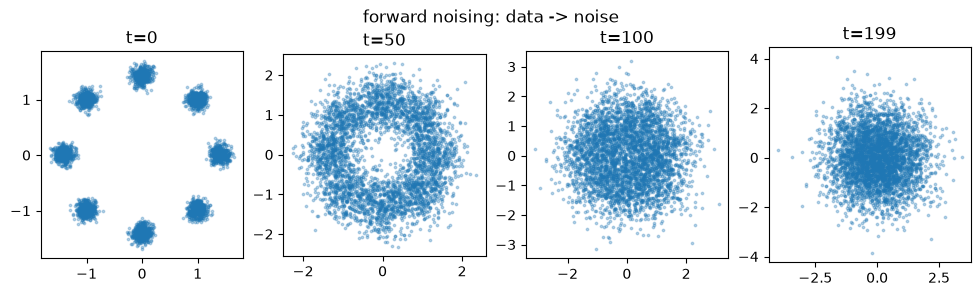

In [6]:
# forward noising: watch the 8 Gaussians dissolve into pure noise
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, ti in zip(axes, [0, T // 4, T // 2, T - 1]):
    tt = torch.full((x0.shape[0],), ti, device=device, dtype=torch.long)
    xi = q_sample(x0, tt, sched)[0].cpu().numpy()
    ax.scatter(xi[:, 0], xi[:, 1], s=3, alpha=0.3)
    ax.set_title(f"t={ti}"); ax.set_aspect("equal")
fig.suptitle("forward noising: data -> noise"); plt.show()

### Exercise 2 — Train the noise predictor (the DDPM objective)

Training a diffusion model is one line of intuition: **noise a sample to a
random step `t`, ask the model to predict the noise, minimise the MSE.** That
is exactly what `ddpm_p_losses(model, x0, t, sched)` does.

Write the `step_fn` that draws a **random timestep per sample** and returns the
DDPM loss, train the `ToyMLP`, and report the **final epoch's mean loss** as
`final_loss`.

In [7]:
# cadence:checkpoint ex2-train-predictor
# cadence:starter
def ddpm_step(model, batch):
    x0 = batch[0]
    # the DDPM trick: pick a DIFFERENT random timestep for each sample in the batch
    t = ...
    return ddpm_p_losses(model, x0, t, sched)

# move the schedule tensors onto the device, then train:
sched = {k: v.to(device) for k, v in sched.items()}
history = train(toy_model, toy_loader, ddpm_step, epochs=EPOCHS, lr=2e-3, device=device)
final_loss = round(float(history[-1]), 4)
print("final training loss:", final_loss)
# cadence:end
# cadence:hint One random step per sample: t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=x0.device).

def ddpm_step(model, batch):
    x0 = batch[0]
    t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=x0.device)
    return ddpm_p_losses(model, x0, t, sched)

sched = {k: v.to(device) for k, v in sched.items()}
history = train(toy_model, toy_loader, ddpm_step, epochs=EPOCHS, lr=2e-3, device=device)
final_loss = round(float(history[-1]), 4)
print("final training loss:", final_loss)

final_loss

train:   0%|          | 0/40 [00:00<?, ?it/s]

/Users/liv/teaching/ml4hep/gen-hep-notebooks/notebooks/../src/train.py:48: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  running += float(loss) * (len(batch[0]) if isinstance(batch, (list, tuple)) else len(batch))


final training loss: 0.5217


0.5217

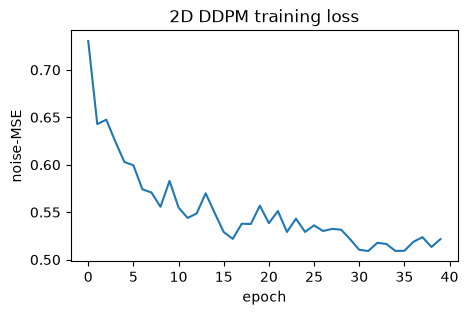

In [8]:
# the 2D DDPM training loss (noise-prediction MSE)
plt.figure(figsize=(5, 3))
plt.plot(history); plt.xlabel("epoch"); plt.ylabel("noise-MSE")
plt.title("2D DDPM training loss"); plt.show()

### Exercise 3 — Reverse denoising: does it recover the data?

Now run the **reverse** process. `ddpm_sample(model, shape, sched, device)`
starts from pure noise and denoises step-by-step back to (hopefully) the data
manifold. Generate **2000** points, plot them over the real data, and measure
how well they match by comparing the **per-coordinate standard deviation** of
generated vs real (both should be ~1 in normalised space).

Set `recovered` (a **bool**) to `True` if the mean absolute difference in those
two standard deviations is below `0.25` — i.e. the reverse process actually
reconstructed the spread of the distribution.

In [ ]:
# cadence:checkpoint ex3-reverse-denoise
# cadence:starter
toy_model.eval()
gen = ddpm_sample(toy_model, (2000, 2), sched, device=device).cpu().numpy()
gen_std = gen.std(0)               # per-coordinate std of the generated points
real_std = X2d.numpy().std(0)      # per-coordinate std of the real (normalised) points
std_gap = ...                      # the mean absolute difference between gen_std and real_std
recovered = ...                    # True if std_gap is below 0.25
print("std gap:", round(std_gap, 3), "| recovered:", recovered)
# cadence:end
# cadence:hint std_gap = np.mean(np.abs(gen_std - real_std)); then recovered = std_gap < 0.25.

toy_model.eval()
gen = ddpm_sample(toy_model, (2000, 2), sched, device=device).cpu().numpy()
gen_std = gen.std(0)
real_std = X2d.numpy().std(0)
std_gap = float(np.mean(np.abs(gen_std - real_std)))
recovered = bool(std_gap < 0.25)
print("std gap:", round(std_gap, 3), "| recovered:", recovered)

recovered

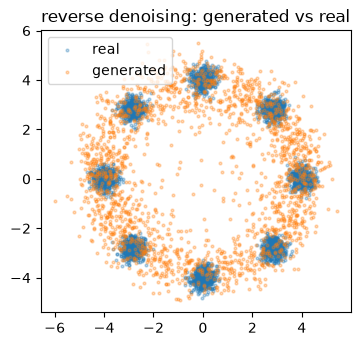

In [10]:
# generated points overlaid on the real 8 Gaussians (de-normalised for a fair view)
gen_real = gen * data_std + data_mean
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(points[:, 0], points[:, 1], s=4, alpha=0.3, label="real")
ax.scatter(gen_real[:, 0], gen_real[:, 1], s=4, alpha=0.3, label="generated")
ax.legend(); ax.set_aspect("equal"); ax.set_title("reverse denoising: generated vs real"); plt.show()

## Part B · Grow a creature from noise 🐲

The 2D toy showed the whole mechanism. For images we let `diffusers` do the
heavy lifting: a `UNet2DModel` noise predictor and a `DDPMScheduler`. We load
**creature sprites** — openly-licensed **Twemoji** (CC-BY) animals & monsters,
augmented with flips/rotations (synthetic blobs if the sprite cache isn't built
yet) — treat them as `(N, 3, 32, 32)` in `[0, 1]`, and train the diffuser
briefly. Then we sample a brand-new monster and **watch it emerge from noise**.

In [11]:
sprites = load_images("sprites", n=2000, image_size=32)   # (N, 3, 32, 32) in [0,1]
S = torch.as_tensor(sprites, dtype=torch.float32)
# diffusers UNets expect inputs roughly in [-1, 1]:
S = S * 2.0 - 1.0
sprite_loader = to_loader(S, batch_size=64)

unet = make_unet(sample_size=32, in_channels=3, base_channels=64).to(device)
scheduler = make_scheduler(num_train_timesteps=1000)
print("sprites:", tuple(S.shape),
      "| UNet params:", sum(p.numel() for p in unet.parameters()))


def sprite_step(model, batch):
    """diffusers training step: add scheduler noise at random t, predict it."""
    x0 = batch[0]
    noise = torch.randn_like(x0)
    t = torch.randint(0, scheduler.config.num_train_timesteps,
                      (x0.shape[0],), device=x0.device).long()
    noisy = scheduler.add_noise(x0, noise, t)
    pred = model(noisy, t).sample
    return F.mse_loss(pred, noise)


@torch.no_grad()
def sprite_sample(model, scheduler, n=4, record_every=100):
    """Reverse the scheduler from pure noise, recording intermediate frames.
    Returns (final_images, frames) with images in [0, 1]."""
    model.eval()
    x = torch.randn(n, 3, 32, 32, device=device)
    frames = []
    for i, t in enumerate(scheduler.timesteps):
        pred = model(x, t).sample
        x = scheduler.step(pred, t, x).prev_sample
        if record_every and (i % record_every == 0 or i == len(scheduler.timesteps) - 1):
            frames.append(((x[0].clamp(-1, 1) + 1) / 2).cpu().numpy())
    final = ((x.clamp(-1, 1) + 1) / 2).cpu().numpy()
    return final, frames

SPRITE_EPOCHS = 6        # brief: a few minutes on one GPU; bump for nicer monsters
print("sprite training config:", SPRITE_EPOCHS, "epochs")

[data] loaded 2000 Twemoji sprites from /Users/liv/teaching/ml4hep/gen-hep-notebooks/data/sprites_32.npz (63 base emoji)
sprites: (2000, 3, 32, 32) | UNet params: 4407043
sprite training config: 6 epochs


### Exercise 4 — Grow a creature and submit your gif 🐲

The fun one. Train the sprite UNet briefly with the provided `sprite_step` (use
`train(...)` with `SPRITE_EPOCHS`), then call `sprite_sample(...)` to denoise from
pure noise while **recording a frame every 100 steps** — you'll watch a monster
condense out of static.

The cell stitches your frames into an animated gif and **submits it** with
`submit_image`, so the teacher can watch your creature emerge. Bump
`SPRITE_EPOCHS` for a crisper monster — it's slow on CPU.

In [ ]:
# cadence:checkpoint ex4-creature-gif manual
# cadence:starter
# train the sprite diffuser, then denoise from noise recording a frame every 100 steps:
unet_hist = train(unet, sprite_loader, sprite_step, epochs=SPRITE_EPOCHS, lr=1e-4, device=device)
final_imgs, frames = sprite_sample(unet, scheduler, n=4, record_every=100)

# stitch the frames into a gif and submit it for the teacher to see:
import imageio
gif_frames = [(np.transpose(np.clip(f, 0, 1), (1, 2, 0)) * 255).astype("uint8") for f in frames]
imageio.mimsave("creature_emerges.gif", gif_frames, duration=0.3)
submit_image("ex4-creature-gif", open("creature_emerges.gif", "rb").read())
print(f"submitted a {len(frames)}-frame creature gif")
# cadence:end

# teacher reference (no submit — the teacher has no student session):
unet_hist = train(unet, sprite_loader, sprite_step, epochs=SPRITE_EPOCHS, lr=1e-4, device=device)
final_imgs, frames = sprite_sample(unet, scheduler, n=4, record_every=100)
print("recorded frames:", len(frames))

train:   0%|          | 0/6 [00:00<?, ?it/s]

In [13]:
# your creature emerging, frame by frame:
fig, axes = plt.subplots(1, len(frames), figsize=(2 * len(frames), 2))
for ax, f in zip(np.atleast_1d(axes), frames):
    ax.imshow(np.transpose(np.clip(f, 0, 1), (1, 2, 0))); ax.axis("off")
fig.suptitle("a creature emerging from noise"); plt.show()

NameError: name 'frames' is not defined

### Exercise 5 — What does the network actually predict? (reflection)

The single most important idea in DDPM. At each reverse step the network does
**not** output the clean image — it looks at the noisy sample `x_t` and predicts
something we subtract a little of to step back toward the data. Write 2–3
sentences and submit:

- In one phrase, what does the model predict at each step?
- Why is predicting *that* an easier, more stable learning target than asking the
  network to output the clean image directly?

In [ ]:
# cadence:checkpoint ex5-predicts manual
# cadence:starter
# Your reflection (2-3 sentences), then run the cell to submit:
#   * what does the model predict at each reverse step?
#   * why is that an easier target than predicting the clean image directly?
# cadence:end

### Exercise 6 — Diffusion vs VAE vs GAN (reflection)

You've now built all three generative families. Write 2–3 sentences comparing
them, using what you saw:

- Diffusion samples are typically **sharper** than the VAE's (notebook 01) and it
  **trains more stably** than the GAN (notebook 02) — what's the price you pay for
  that? (Think about how many network passes it takes to make *one* sample.)
- For a physics generator where you'll throw **millions** of samples, which
  tradeoff would worry you most?

In [ ]:
# cadence:checkpoint ex6-compare manual
# cadence:starter
# Your reflection (2-3 sentences), then run the cell to submit:
#   * diffusion is sharper than a VAE and more stable than a GAN — what does it
#     cost you? (hint: how many network passes to make one sample?)
#   * which tradeoff matters most for generating millions of physics samples?
# cadence:end

## Recap

- **Diffusion = learn to reverse noise.** Forward: add Gaussian noise over many
  small steps until data is pure noise. Reverse: a network **predicts the noise**
  and we subtract a little at each step to walk back to data.
- The **training objective is just an MSE on the predicted noise** — you saw it
  on the 2D toy with a 2-layer MLP, and the *same* idea drives the `diffusers`
  UNet that grew a creature sprite from static.
- Diffusion samples are typically **sharper** than a VAE's (notebook 01) and
  **train more stably** than a GAN (notebook 02) — at the cost of many sampling
  steps. We'll put it to work on **calorimeter showers** next (notebook 04).

<!-- cadence:hide -->
## Generate the cadence notebooks

Run this **after** *Run All* above, so every exercise's answer value is in the kernel. `%cadence_autoregister` auto-detects each `##`-headed exercise, registers a checkpoint from the cell's final value, and writes `<this>_registered.ipynb` — which in turn writes the student notebook via the `%cadence_scaffold` cell it appends.
<!-- cadence:end -->

In [15]:
%cadence_autoregister --reveal-after 4

id,comparator,expected
ex1-forward-noise,numeric,1.002
ex2-train-predictor,numeric,0.5217
ex3-reverse-denoise,exact,true
ex4-creature-gif,manual,—
ex5-predicts,manual,—
ex6-compare,manual,—


/Users/liv/teaching/ml4hep/gen-hep-notebooks/notebooks/03_diffusion_intro_registered.ipynb